# Neural Network Anatomy

# 1. Perceptron & Single Neuron

## 1.1 Dari Neuron Biologis ke Artificial Neuron

Secara biologis, neuron menerima sinyal dari neuron lain melalui dendrite, mengakumulasikan sinyal tersebut di badan sel (soma), lalu jika akumulasi melewati ambang batas tertentu, neuron akan "menembak" (fire) sinyal output melalui axon. Mekanisme menerima–mengakumulasi–memutuskan inilah yang menjadi inspirasi longgar bagi model matematis neuron buatan — bukan tiruan presisi, melainkan abstraksi.

Model formal pertama diperkenalkan McCulloch & Pitts (1943), lalu disempurnakan menjadi Perceptron oleh Frank Rosenblatt (1958) — salah satu model trainable pertama dalam sejarah machine learning. Satu neuron buatan pada dasarnya melakukan dua operasi berurutan: agregasi linear terhadap input, lalu keputusan non-linear terhadap hasil agregasi tersebut.

Dua hal penting untuk dipegang sejak awal:

* Neuron buatan bukan simulasi biologis, melainkan abstraksi matematis yang terinspirasi darinya.
* Kekuatan neural network tidak datang dari satu neuron, melainkan dari komposisi ribuan/jutaan neuron sederhana yang disusun berlapis.

## 1.2 Komponen Penyusun Artificial Neuron

* Input $(x_1, x_2, \dots, x_n)$ > nilai numerik fitur yang masuk ke nueron
* Weight $(w_1, w_2, \dots, w_n)$ > Perameter yang menentukan kontribusi tiap output terhadap hasil akhir, parameter yang dipelajari selama training
* bias $(b)$ : Parameter tambahan, independen dari input, yang menggeser hasil agregasi. Analog dengan intercept pada regresi linear.
* Weighted sum $(z)$ : akumulasi seluruh input terkalikan weightnya ditambah bias
* Activation Function $(f)$ : fungsi yang diterpakan pada $z$ untuk menghasilkan output akhir; biasanya non linear
* Output ($\hat{y}$) : hasil akhir neuron, berupa nilai kontinu atau probabilitas tergantung pilihan activation 

## 1.3 Formulasi Matematis

Weighted sum:

$$z = w_1 x_1 + w_2 x_2 + \dots + w_n x_n + b = \sum_{i=1}^{n} w_i x_i + b$$

Output neuron adalah hasil activation terhadap $z$:

$$\hat{y} = f(z)$$

Dalam notasi vektor — bentuk yang langsung dipakai di NumPy maupun (nanti) PyTorch:

$$z = \mathbf{w}^\top \mathbf{x} + b$$

dengan $\mathbf{w}^\top \mathbf{x}$ adalah *dot product*  antara weight dan input Notasi ini penting dikuasai lebih awal karena seluruh komputasi neural network modern direpresentasikan sebagai operasi vektor/matrix, bukan perkalian skalar satu per satu.

> Catatan praktis: jika  familiar dengan logistic regression, formulasi ini akan terasa akrab — logistic regression pada dasarnya adalah satu neuron dengan activation sigmoid. Perbedaan neural network terletak pada penyusunan banyak neuron seperti ini secara berlapis.

## 1.4 Alur Komputasi: Dari Input ke Output

```text
Input (x)
   │
   ▼
Weight × Input (w · x)
   │
   ▼
Weighted Sum + Bias  →  z = Σ(w·x) + b
   │
   ▼
Activation  →  ŷ = f(z)
   │
   ▼
Output (ŷ)

Contoh Perhitungan Manual

Diketahui:
* Input: $\mathbf{x} = [0.6, 0.9]^\top$
* Bobot: $\mathbf{w} = [0.4, -0.2]^\top$
* Bias: $b = 0.1$
* Fungsi Aktivasi Sigmoid: $\sigma(z) = \frac{1}{1 + e^{-z}}$

**1. Menghitung Kombinasi Linier ($z$):**
$$z = \mathbf{w}^\top \mathbf{x} + b$$
$$z = (0.4)(0.6) + (-0.2)(0.9) + 0.1$$
$$z = 0.24 - 0.18 + 0.1 = 0.16$$

**2. Menghitung Prediksi / Output ($\hat{y}$):**
$$\hat{y} = \sigma(0.16) = \frac{1}{1 + e^{-0.16}} \approx 0.540$$

## 1.5 Intuisi: Pengaruh Weight dan Bias

* **Weight** mengatur kemiringan (*slope*) dan sensitivitas. Weight besar (positif/negatif) membuat neuron sangat sensitif terhadap perubahan kecil pada input terkait; weight mendekati nol membuat neuron nyaris mengabaikan input tersebut; weight negatif membalik arah hubungan.

* **Bias** menggeser (*shift*) hasil, bukan mengubah kemiringan. *Decision boundary* neuron adalah himpunan titik di mana $z = 0$, yaitu:
$$\mathbf{w}^\top \mathbf{x} + b = 0$$

* Bias menggeser posisi *boundary* tanpa mengubah orientasinya. Tanpa bias, *boundary* selalu melewati *origin* $(0,0)$ — sebuah batasan signifikan, karena banyak dataset riil tidak bisa dipisahkan dengan baik oleh garis/hyperplane yang dipaksa melewati titik $(0,0)$.

## 1.6. Implementasi (NumPy)

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [3]:
def sigmoid(z):
    """Memetakan z (real number apapun) ke rentang (0, 1)."""
    return 1 / (1 + np.exp(-z))

# Single neuron forward computation
def neuron_forward(x, w, b, activation=sigmoid):
    """
    Menghitung weighted sum (z) dan output (y_hat) satu neuron
    
    Paramters
    ---------
    x : np.ndarray, shape (n_features,)
        Vektor input.
    w : np.ndarray, shape (n_features,)
        Vektor weight, satu nilai per feature input.
    b : float
        Bias (skalar).
    activation : callable
        Fungsi aktivasi yang diterapkan pada z.
        
    Returns
    -------
    z : float      -> weighted sum sebelum activation
    y_hat : float  -> output setelah activation
    """
    
    z = np.dot(w, x) + b   # w1*x1 + w2*x2 + ... + wn*xn + b
    y_hat = activation(z)
    
    return z, y_hat

# Verifikasi terhadap perhitungan manual di 1.4
x = np.array([0.6, 0.9])
w = np.array([0.4, -0.2])
b = 0.1

z, y_hat = neuron_forward(x, w, b)
print(f"z (weighted sum) = {z:.4f}")      # harus ≈ 0.1600
print(f"y_hat (output)   = {y_hat:.4f}")



z (weighted sum) = 0.1600
y_hat (output)   = 0.5399


Visualisasi pengaruh weight & bias terhadap decision boundary

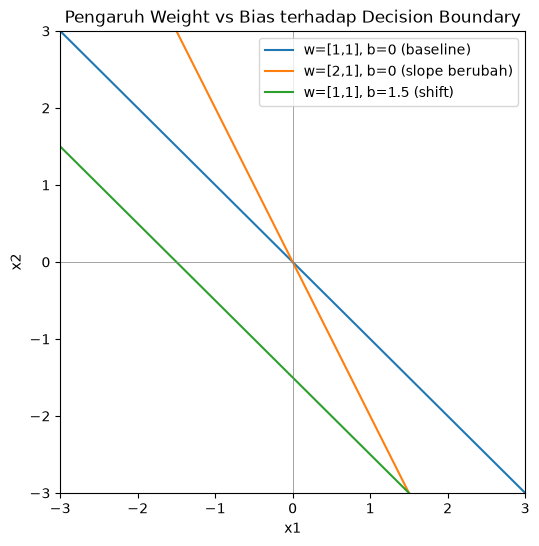

In [4]:
# --------------------------------------------------------------------
# Decision boundary: w1*x1 + w2*x2 + b = 0  ->  x2 = -(w1*x1 + b) / w2
# --------------------------------------------------------------------
def plot_decision_boundary(w, b, ax, label):
    x1_range = np.linspace(-3, 3, 100)
    x2_range = -(w[0] * x1_range + b) / w[1]
    ax.plot(x1_range, x2_range, label=label)

fig, ax = plt.subplots(figsize=(6, 6))

# Baseline
plot_decision_boundary(w=np.array([1.0, 1.0]), b=0.0, ax=ax, label="w=[1,1], b=0 (baseline)")

# Weight diubah -> kemiringan garis berubah
plot_decision_boundary(w=np.array([2.0, 1.0]), b=0.0, ax=ax, label="w=[2,1], b=0 (slope berubah)")

# Bias diubah -> garis bergeser, kemiringan TETAP sama seperti baseline
plot_decision_boundary(w=np.array([1.0, 1.0]), b=1.5, ax=ax, label="w=[1,1], b=1.5 (shift)")

ax.axhline(0, color="gray", linewidth=0.5)
ax.axvline(0, color="gray", linewidth=0.5)
ax.set_xlim(-3, 3)
ax.set_ylim(-3, 3)
ax.set_xlabel("x1")
ax.set_ylabel("x2")
ax.set_title("Pengaruh Weight vs Bias terhadap Decision Boundary")
ax.legend()
plt.show()

Amati hasil plot: garis oranye (weight berubah) memiliki kemiringan berbeda dari garis biru, sementara garis hijau (bias berubah) sejajar dengan garis biru namun bergeser posisinya.

## Latihan

1. **Hitung Manual**  
   Untuk $\mathbf{x} = [1, -2]^\top$, $\mathbf{w} = [0.5, 1.5]^\top$, dan $b = -0.5$:
   * Hitung $z$ dan $\hat{y}$ (menggunakan fungsi aktivasi Sigmoid) di atas kertas terlebih dahulu.
   * Setelah itu, verifikasi hasilnya menggunakan fungsi `neuron_forward`.

2. **Eksperimen Weight**  
   Ubah salah satu nilai $\mathbf{w}$ menjadi jauh lebih besar (misalnya $10$), jalankan ulang `plot_decision_boundary`, lalu jelaskan dengan kalimat sendiri apa yang terjadi pada kemiringan garis dan mengapa hal tersebut terjadi.

3. **Eksperimen Bias**  
   Tetapkan $\mathbf{w} = [1, 1]^\top$, lalu plot *decision boundary* untuk $b = -2$, $b = 0$, dan $b = 2$ dalam satu grafik. Pastikan Anda dapat menjelaskan mengapa ketiga garis tersebut sejajar.

4. **Reflektif (Tanpa Kode)**  
   Jika neuron tidak memiliki bias (selalu $b = 0$), *decision boundary*-nya akan selalu melewati *origin* $(0, 0)$. Menurut Anda, bentuk dataset seperti apa yang tidak bisa dipisahkan dengan baik oleh neuron semacam ini?